# Circuit Breakers for Trading Systems

**Chapter 26: MLOps and Governance**
**Docker image**: `ml4t`
**Book Reference**: Chapter 26, Section 26.5
**Prerequisites**: Chapter 25 deployment verification and the Chapter 26 monitoring sections.

**Learning Objectives**:
- Build one state machine that decides when an automated system stops trading, when it may
  try again, and when it is back to normal, and reuse it for every rule that can halt.
- Write four halt rules that each catch a different way a strategy fails, and combine them
  into a single answer to the question the trading engine asks: may I trade right now.
- Keep an audit log that records every state change, so an operator can reconstruct after
  the fact which rule stopped trading and why.
- Tell a market-driven halt apart from an infrastructure-driven one, since the response to
  each is different.

A **circuit breaker** is a rule that switches a system off when a measurement crosses a
limit, and switches it back on only after a defined test. Borrowed from electrical
engineering, and used the same way here: the point is not the limit, it is that switching
off is automatic and switching back on is not.

Four are built below. A drawdown breaker on the equity curve, a daily-loss breaker, a
consecutive-loss breaker and a latency breaker. Section 26.5 of the chapter lists more
(weekly drawdown, position size, sector, volatility, spread, intraday move); each of them is
the same state machine with a different condition, which is the reason the state machine is
separated out first.

In [1]:
"""Circuit Breakers for Trading Systems: a shared halt state machine with four independent rules."""

import warnings
from abc import ABC, abstractmethod
from collections.abc import Callable
from dataclasses import dataclass
from datetime import datetime, timedelta
from enum import Enum, auto
from typing import cast

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

# Named, not blanket: a bare ignore would also hide the convergence and numerical
# warnings a reader needs to see.
warnings.filterwarnings("ignore", category=FutureWarning, module="polars")

## Settings

**The simulation.** `SIMULATION_START` and `N_STEPS` pick the market history the breakers
run over: the first `N_STEPS` sessions of SPY from that date. `INITIAL_VALUE` is the account
the simulation starts from, and it only sets the scale of the numbers.

**The four limits.** `MAX_DRAWDOWN` is how far below its own running peak the account may
fall; `MAX_DAILY_LOSS` how much it may lose within one session, measured from that session's
opening value rather than from inception; `MAX_CONSECUTIVE_LOSSES` how many losing sessions
in a row are tolerated; and `MAX_LATENCY_MS` how slow the system's own round trip may get.
The four are set at levels that a real desk would recognise and are not derived from
anything here: what a desk can absorb is a question about its capital and its investors,
and no calculation in this notebook answers it.

**Coming back on.** Each breaker has its own recovery timeout, and they differ because the
conditions clear at different speeds. Latency recovers in minutes if a queue drains; a
drawdown does not, so its timeout is hours. After the timeout the breaker does not close, it
moves to a half-open state and lets the next observation decide.

**What the breakers read.** `LATENCY_WINDOW` is how many recent measurements the latency
breaker averages before comparing against its limit, so one slow round trip does not halt
trading; `LATENCY_HISTORY` caps what it retains.

**The synthetic latency stream.** There is no recorded system-latency series in this
repository, so the latency breaker is driven by draws from an exponential distribution:
`LATENCY_NORMAL_MS` is its mean while the system is healthy and `LATENCY_STRESSED_MS` after
`LATENCY_STRESS_FRACTION` of the run, at which point the rolling average crosses the limit.
The market path, by contrast, is real.

In [2]:
SIMULATION_START = "2020-01-02"
N_STEPS = 100
INITIAL_VALUE = 100_000
MAX_DRAWDOWN = 0.10
MAX_DAILY_LOSS = 0.02
MAX_CONSECUTIVE_LOSSES = 5
MAX_LATENCY_MS = 100.0
DRAWDOWN_RECOVERY_HOURS = 4
DAILY_LOSS_RECOVERY_HOURS = 1
CONSECUTIVE_LOSS_RECOVERY_MINUTES = 30
LATENCY_RECOVERY_MINUTES = 5
LATENCY_WINDOW = 10
LATENCY_HISTORY = 100
LATENCY_NORMAL_MS = 20.0
LATENCY_STRESSED_MS = 150.0
LATENCY_STRESS_FRACTION = 0.8
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. The state machine every breaker shares

A breaker is in one of three states. **Closed** is the electrical sense of the word: the
circuit is complete and trading proceeds. **Open** means the circuit is broken and nothing
trades. **Half-open** is the state between them: enough time has passed that the breaker is
willing to look again, and the next observation either closes it or opens it for another
timeout.

The half-open state is the part worth building deliberately. A breaker that closed as soon
as its timeout elapsed would resume trading into whatever condition tripped it; one that
only closed on manual intervention would need a person awake. Half-open resumes on evidence.

In [4]:
class BreakerState(Enum):
    """Circuit breaker state."""

    CLOSED = auto()  # Normal operation
    OPEN = auto()  # Halted - no trading
    HALF_OPEN = auto()  # Testing - limited trading

Breaker events are the audit trail. Each state change records the reason and
the threshold that triggered it.

In [5]:
@dataclass
class BreakerEvent:
    """Event that triggered breaker."""

    timestamp: datetime
    breaker_name: str
    old_state: BreakerState
    new_state: BreakerState
    reason: str
    value: float | None = None
    threshold: float | None = None

The base circuit breaker implements the shared state machine. Specific
breakers only need to define their own trip condition.

In [6]:
def transition_breaker(
    breaker,
    new_state: BreakerState,
    reason: str,
    value: float | None = None,
    threshold: float | None = None,
    event_time: datetime | None = None,
) -> None:
    event_time = event_time or datetime.now()
    event = BreakerEvent(
        timestamp=event_time,
        breaker_name=breaker.name,
        old_state=breaker.state,
        new_state=new_state,
        reason=reason,
        value=value,
        threshold=threshold,
    )
    breaker.history.append(event)
    breaker.state = new_state
    if new_state == BreakerState.OPEN and event.old_state != BreakerState.OPEN:
        breaker.trip_count += 1
        breaker.trip_time = event_time
    # Audit-trail callback fires on every transition (CLOSED↔OPEN, OPEN→HALF_OPEN,
    # HALF_OPEN↔CLOSED/OPEN). on_trip fires only when the transition lands in OPEN
    # so manager-level alerting stays specific to trips.
    if breaker.on_transition:
        breaker.on_transition(event)
    if breaker.on_trip and new_state == BreakerState.OPEN:
        breaker.on_trip(event)

Keep the transition logic outside the class so each concrete breaker can
inherit a compact, readable state machine.

In [7]:
def advance_breaker_state(
    breaker, event_time: datetime | None = None, **kwargs: object
) -> BreakerState:
    event_time = event_time or datetime.now()
    if breaker.state == BreakerState.OPEN:
        if breaker.trip_time and event_time - breaker.trip_time >= breaker.recovery_timeout:
            transition_breaker(
                breaker, BreakerState.HALF_OPEN, "Recovery timeout elapsed", event_time=event_time
            )
        return breaker.state

    should_trip, reason, value, threshold = breaker.check_condition(**kwargs)
    if should_trip:
        if breaker.state == BreakerState.HALF_OPEN:
            transition_breaker(
                breaker,
                BreakerState.OPEN,
                f"Recovery failed: {reason}",
                value,
                threshold,
                event_time,
            )
        else:
            transition_breaker(breaker, BreakerState.OPEN, reason, value, threshold, event_time)
    elif breaker.state == BreakerState.HALF_OPEN:
        transition_breaker(
            breaker, BreakerState.CLOSED, "Recovery successful", event_time=event_time
        )
    return breaker.state

The abstract base class now delegates the mechanics to helper functions and
keeps only the public interface shared across breaker types.

In [8]:
class CircuitBreaker(ABC):
    def __init__(
        self,
        name: str,
        recovery_timeout: timedelta = timedelta(hours=1),
        on_trip: Callable[[BreakerEvent], None] | None = None,
        on_transition: Callable[[BreakerEvent], None] | None = None,
    ):
        self.name = name
        self.recovery_timeout = recovery_timeout
        self.on_trip = on_trip
        self.on_transition = on_transition

        self.state = BreakerState.CLOSED
        self.trip_time: datetime | None = None
        self.trip_count = 0
        self.history: list[BreakerEvent] = []

    @abstractmethod
    def check_condition(
        self, portfolio_value: float | None = None, **kwargs: object
    ) -> tuple[bool, str, float | None, float | None]:
        pass

    def update(self, event_time: datetime | None = None, **kwargs: object) -> BreakerState:
        return advance_breaker_state(self, event_time=event_time, **kwargs)

    def _transition(self, new_state, reason, value=None, threshold=None, event_time=None):
        transition_breaker(self, new_state, reason, value, threshold, event_time)

    def reset(self, event_time: datetime | None = None):
        """Manually reset breaker to CLOSED."""
        self._transition(BreakerState.CLOSED, "Manual reset", event_time=event_time)
        self.trip_time = None

    def is_open(self) -> bool:
        """Check if trading is halted."""
        return self.state == BreakerState.OPEN

    def allows_trading(self) -> bool:
        """Check if trading is allowed."""
        return self.state in [BreakerState.CLOSED, BreakerState.HALF_OPEN]

Everything above is shared. A concrete breaker below supplies only `check_condition`, which
answers one question - has my limit been crossed - and returns the value and threshold so the
audit log can record why. That is the whole extension point: a new rule is a condition, not a
framework.

## 2. Specific Circuit Breaker Implementations

The drawdown breaker trips when the running peak-to-current decline exceeds a
threshold:

$$DD_t = 1 - \frac{V_t}{\max_{u \le t} V_u}$$

where $V_t$ is portfolio value at step $t$.

In [9]:
class DrawdownBreaker(CircuitBreaker):
    """Trips when drawdown from the running peak exceeds a threshold."""

    def __init__(
        self,
        name: str,
        max_drawdown: float = MAX_DRAWDOWN,
        **kwargs,
    ):
        super().__init__(name, **kwargs)
        self.max_drawdown = max_drawdown
        self.peak_value = 0

    def check_condition(
        self, portfolio_value: float | None = None, **kwargs: object
    ) -> tuple[bool, str, float | None, float | None]:
        if portfolio_value is None:
            return False, "", None, None

        # Update peak
        self.peak_value = max(self.peak_value, portfolio_value)

        if self.peak_value == 0:
            return False, "", None, None

        drawdown = (self.peak_value - portfolio_value) / self.peak_value

        if drawdown >= self.max_drawdown:
            return True, f"Drawdown {drawdown:.1%} exceeds limit", drawdown, self.max_drawdown

        return False, "", drawdown, self.max_drawdown

Daily loss controls and consecutive-loss controls catch different failure
modes: a sharp intraday shock versus a strategy repeatedly making poor bets.

In [10]:
class DailyLossBreaker(CircuitBreaker):
    """
    Trips when daily loss exceeds threshold.
    """

    def __init__(
        self,
        name: str,
        max_daily_loss: float = MAX_DAILY_LOSS,
        **kwargs,
    ):
        super().__init__(name, **kwargs)
        self.max_daily_loss = max_daily_loss
        self.start_of_day_value: float | None = None

    def reset_day(self, current_value: float):
        """Call at start of trading day."""
        self.start_of_day_value = current_value

    def check_condition(
        self, portfolio_value: float | None = None, **kwargs: object
    ) -> tuple[bool, str, float | None, float | None]:
        if portfolio_value is None:
            return False, "", None, None

        if self.start_of_day_value is None:
            self.start_of_day_value = portfolio_value
            return False, "", None, None

        daily_pnl = (portfolio_value - self.start_of_day_value) / self.start_of_day_value

        if daily_pnl <= -self.max_daily_loss:
            return (
                True,
                f"Daily loss {abs(daily_pnl):.1%} exceeds limit",
                daily_pnl,
                -self.max_daily_loss,
            )

        return False, "", daily_pnl, -self.max_daily_loss

Consecutive-loss logic is a lightweight proxy for strategy health when losses
come from repeated bad predictions rather than one market shock.

In [11]:
class ConsecutiveLossBreaker(CircuitBreaker):
    """
    Trips after N consecutive losing trades.
    """

    def __init__(
        self,
        name: str,
        max_consecutive: int = MAX_CONSECUTIVE_LOSSES,
        **kwargs,
    ):
        super().__init__(name, **kwargs)
        self.max_consecutive = max_consecutive
        self.consecutive_losses = 0

    def record_trade(self, pnl: float):
        """Record trade result."""
        if pnl < 0:
            self.consecutive_losses += 1
        else:
            self.consecutive_losses = 0

    def check_condition(
        self, portfolio_value: float | None = None, **kwargs: object
    ) -> tuple[bool, str, float | None, float | None]:
        if self.consecutive_losses >= self.max_consecutive:
            return (
                True,
                f"{self.consecutive_losses} consecutive losses",
                float(self.consecutive_losses),
                float(self.max_consecutive),
            )

        return False, "", float(self.consecutive_losses), float(self.max_consecutive)

The fourth breaker watches the system rather than the market. A trading system that has
become slow is acting on prices that have moved, which is a way to lose money that no
market-risk rule sees. It shares the same state machine because the engine asking whether it
may trade should get one answer, not two.

In [12]:
class LatencyBreaker(CircuitBreaker):
    """
    Trips when system latency exceeds threshold.
    """

    def __init__(
        self,
        name: str,
        max_latency_ms: float = MAX_LATENCY_MS,
        **kwargs,
    ):
        super().__init__(name, **kwargs)
        self.max_latency_ms = max_latency_ms
        self.latency_history: list[float] = []

    def record_latency(self, latency_ms: float):
        """Record operation latency."""
        self.latency_history.append(latency_ms)
        self.latency_history = self.latency_history[-LATENCY_HISTORY:]

    def check_condition(
        self, portfolio_value: float | None = None, **kwargs: object
    ) -> tuple[bool, str, float | None, float | None]:
        if not self.latency_history:
            return False, "", None, None

        avg_latency = float(np.mean(self.latency_history[-LATENCY_WINDOW:]))

        if avg_latency > self.max_latency_ms:
            return (
                True,
                f"Latency {avg_latency:.1f}ms exceeds limit",
                avg_latency,
                self.max_latency_ms,
            )

        return False, "", avg_latency, self.max_latency_ms

None of the four conditions is sophisticated, and that is deliberate. What protects a desk
is that they fail in different circumstances: a single shock trips the daily-loss rule, a
slow bleed trips the drawdown rule, a broken signal trips the streak rule, and a degraded
system trips the latency rule. A more elaborate single rule covers one of those better and
the other three not at all.

## 3. Breaker Manager: Multi-Level Defense

In [13]:
def make_trip_callback(
    manager,
    breaker: CircuitBreaker,
) -> Callable[[BreakerEvent], None]:
    """Wrap the breaker's on_trip so manager-level trip alerts also fire."""
    original_callback = breaker.on_trip

    def wrapped_callback(event: BreakerEvent):
        if original_callback:
            original_callback(event)
        if manager.on_any_trip:
            manager.on_any_trip(event)

    return wrapped_callback

In [14]:
def make_transition_logger(manager) -> Callable[[BreakerEvent], None]:
    """Append every breaker transition to the manager's audit log."""

    def log_transition(event: BreakerEvent):
        manager.event_log.append(event)

    return log_transition

The manager is mostly a small coordination layer: registration, centralized
status, and a single event log for all breaker trips.

In [15]:
class BreakerManager:
    """
    Manages multiple circuit breakers with hierarchical levels.

    If any breaker trips, trading is halted.
    """

    def __init__(self, on_any_trip: Callable[[BreakerEvent], None] | None = None):
        self.breakers: dict[str, CircuitBreaker] = {}
        self.on_any_trip = on_any_trip
        self.event_log: list[BreakerEvent] = []

    def add_breaker(self, breaker: CircuitBreaker):
        breaker.on_trip = make_trip_callback(self, breaker)
        breaker.on_transition = make_transition_logger(self)
        self.breakers[breaker.name] = breaker

    def check_all(self, **kwargs) -> bool:
        for breaker in self.breakers.values():
            breaker.update(**kwargs)
        return all(b.allows_trading() for b in self.breakers.values())

    def get_status(self) -> dict[str, dict]:
        """Get status of all breakers."""
        return {
            name: {
                "state": breaker.state.name,
                "trip_count": breaker.trip_count,
                "allows_trading": breaker.allows_trading(),
            }
            for name, breaker in self.breakers.items()
        }

    def reset_all(self, event_time: datetime | None = None):
        """Reset all breakers."""
        for breaker in self.breakers.values():
            breaker.reset(event_time=event_time)

The manager centralizes event logging and gives the trading engine one answer
to the question that matters operationally: is trading still allowed?

In [16]:
announced_breakers: set[str] = set()


def alert_handler(event: BreakerEvent):
    """Emit the first trip per breaker; full detail lives in the event log."""
    if event.breaker_name in announced_breakers:
        return
    announced_breakers.add(event.breaker_name)
    detail = f" ({event.value:.4f} vs {event.threshold:.4f})" if event.value is not None else ""
    print(f"ALERT {event.breaker_name}: {event.reason}{detail}")

Configure one breaker for each risk layer so the later simulation can show how
independent protections interact.

In [17]:
manager = BreakerManager(on_any_trip=alert_handler)

# Add breakers at different levels
DRAWDOWN_BREAKER = f"drawdown_{MAX_DRAWDOWN:.0%}"
DAILY_LOSS_BREAKER = f"daily_loss_{MAX_DAILY_LOSS:.0%}"
CONSECUTIVE_LOSS_BREAKER = f"consecutive_{MAX_CONSECUTIVE_LOSSES}"
LATENCY_BREAKER = f"latency_{MAX_LATENCY_MS:.0f}ms"

manager.add_breaker(
    DrawdownBreaker(
        name=DRAWDOWN_BREAKER,
        max_drawdown=MAX_DRAWDOWN,
        recovery_timeout=timedelta(hours=DRAWDOWN_RECOVERY_HOURS),
    )
)

manager.add_breaker(
    DailyLossBreaker(
        name=DAILY_LOSS_BREAKER,
        max_daily_loss=MAX_DAILY_LOSS,
        recovery_timeout=timedelta(hours=DAILY_LOSS_RECOVERY_HOURS),
    )
)

manager.add_breaker(
    ConsecutiveLossBreaker(
        name=CONSECUTIVE_LOSS_BREAKER,
        max_consecutive=MAX_CONSECUTIVE_LOSSES,
        recovery_timeout=timedelta(minutes=CONSECUTIVE_LOSS_RECOVERY_MINUTES),
    )
)

manager.add_breaker(
    LatencyBreaker(
        name=LATENCY_BREAKER,
        max_latency_ms=MAX_LATENCY_MS,
        recovery_timeout=timedelta(minutes=LATENCY_RECOVERY_MINUTES),
    )
)

print(f"Breaker Manager configured with {len(manager.breakers)} breakers.")

Breaker Manager configured with 4 breakers.


Four breakers, four failure modes, one halt decision and one log. `check_all` returns true
only when every breaker allows trading, so adding a breaker can only make the system more
cautious, never less.

## 4. Run the breakers over a real market shock

The market path is SPY's own daily returns from `SIMULATION_START`. Beginning in January 2020
puts the February and March selloff inside the window, so the two loss breakers meet real
sessions with real magnitudes rather than a distribution chosen to trip them.

The latency stream is the exception and is drawn from an exponential distribution, because
this repository holds no recorded system-latency series. The seed is set immediately before
the loop so those draws are reproducible; nothing else in the run is random.

Two limits are recorded from the breakers as the run proceeds, for the figure below. Both
move, which is the reason to take them from the breakers rather than draw them as horizontal
lines: the drawdown limit tracks the running peak, and the daily-loss limit resets every
session to that session's opening value.

In [18]:
set_global_seeds(SEED)

portfolio_values = [INITIAL_VALUE]
trading_allowed = []
breaker_states = {name: [] for name in manager.breakers.keys()}
drawdown_limits: list[float] = []
daily_loss_limits: list[float] = []

One point about what the account value below is, because it changes how the figure should be
read. The series keeps tracking SPY after a breaker halts trading, so from the first halt
onward it is a *counterfactual*: what the account would have done had nothing stopped it. It
is what makes the halts legible, and it is not money anyone made or lost.

In [19]:
covid_returns = (
    load_etfs()
    .filter(
        (pl.col("symbol") == "SPY")
        & (pl.col("timestamp") >= pl.lit(SIMULATION_START).str.to_date())
    )
    .sort("timestamp")
    .with_columns(pl.col("close").pct_change().alias("ret"))
    .drop_nulls("ret")
    .head(N_STEPS)
    .select("timestamp", "ret")
)
if covid_returns.height < N_STEPS:
    raise ValueError(
        f"SPY from {SIMULATION_START} returned {covid_returns.height} sessions; "
        f"the simulation needs {N_STEPS}"
    )

In [20]:
simulation_dates = covid_returns["timestamp"].to_list()
manager.reset_all(event_time=pd.Timestamp(simulation_dates[0]).to_pydatetime())
manager.event_log.clear()  # discard CLOSED→CLOSED reset transitions for a clean audit trail
drawdown_breaker = cast(DrawdownBreaker, manager.breakers[DRAWDOWN_BREAKER])
daily_loss_breaker = cast(DailyLossBreaker, manager.breakers[DAILY_LOSS_BREAKER])
consecutive_loss_breaker = cast(ConsecutiveLossBreaker, manager.breakers[CONSECUTIVE_LOSS_BREAKER])
latency_breaker = cast(LatencyBreaker, manager.breakers[LATENCY_BREAKER])

n_steps = N_STEPS
real_returns = covid_returns["ret"].to_numpy()
for i in range(n_steps):
    event_time = pd.Timestamp(simulation_dates[i]).to_pydatetime()
    # Before the day's return: without this the breaker measures loss from inception.
    start_of_day_value = portfolio_values[-1]
    daily_loss_breaker.reset_day(start_of_day_value)

    returns = float(real_returns[i])
    new_value = start_of_day_value * (1 + returns)
    portfolio_values.append(new_value)

    trade_pnl = new_value - start_of_day_value
    consecutive_loss_breaker.record_trade(trade_pnl)

    stressed = i >= int(n_steps * LATENCY_STRESS_FRACTION)
    latency = np.random.exponential(LATENCY_STRESSED_MS if stressed else LATENCY_NORMAL_MS)
    latency_breaker.record_latency(latency)

    can_trade = manager.check_all(portfolio_value=new_value, event_time=event_time)
    trading_allowed.append(can_trade)
    drawdown_limits.append(drawdown_breaker.peak_value * (1 - drawdown_breaker.max_drawdown))
    daily_loss_limits.append(start_of_day_value * (1 - daily_loss_breaker.max_daily_loss))

    # Record states
    for name, breaker in manager.breakers.items():
        breaker_states[name].append(breaker.state.value)

ALERT daily_loss_2%: Daily loss 3.3% exceeds limit (-0.0332 vs -0.0200)
ALERT consecutive_5: 5 consecutive losses (5.0000 vs 5.0000)
ALERT drawdown_10%: Drawdown 12.1% exceeds limit (0.1207 vs 0.1000)
ALERT latency_100ms: Latency 130.8ms exceeds limit (130.7934 vs 100.0000)


In [21]:
print(f"\nSimulation complete: {n_steps} steps")
print(f"Final portfolio value: ${portfolio_values[-1]:,.2f}")
print(f"Trading halted {sum(not x for x in trading_allowed)} times")


Simulation complete: 100 steps
Final portfolio value: $93,980.65
Trading halted 38 times


The run mixes a real market shock with a synthetic infrastructure one, and they arrive at
different times. That separation is the point of the panels below: both end with trading
halted, and what an operator does next is different in each case.

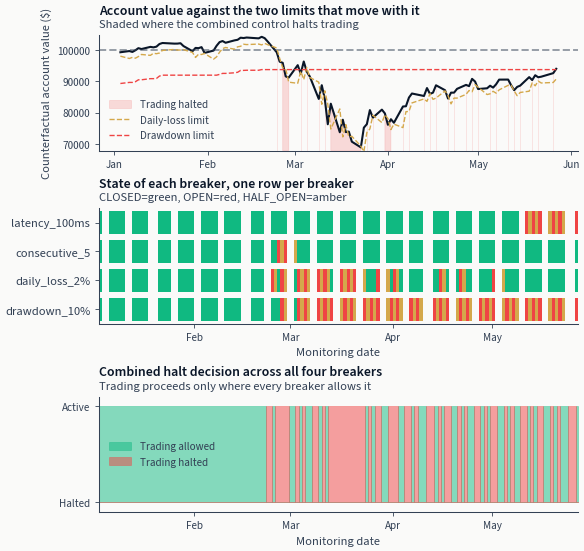

In [22]:
state_colors = {
    BreakerState.CLOSED.value: COLORS["positive"],
    BreakerState.OPEN.value: COLORS["negative"],
    BreakerState.HALF_OPEN.value: COLORS["amber"],
}

fig, axes = plt.subplots(3, 1, figsize=FIGSIZE["grid_3x2"], constrained_layout=True)

ax1 = axes[0]
ax1.plot(simulation_dates, portfolio_values[1:], color=COLORS["blue"], linewidth=1.5)
y_min = min(portfolio_values) * 0.985
y_max = max(portfolio_values) * 1.005
ax1.set_ylim(y_min, y_max)
ax1.fill_between(
    simulation_dates,
    portfolio_values[1:],
    y_min,
    where=[not allowed for allowed in trading_allowed],
    color=COLORS["negative"],
    alpha=0.18,
    label="Trading halted",
)
ax1.axhline(INITIAL_VALUE, color=COLORS["neutral"], linestyle="--", alpha=0.5)
ax1.plot(
    simulation_dates,
    daily_loss_limits,
    color=COLORS["amber"],
    linestyle="--",
    linewidth=1,
    label="Daily-loss limit",
)
ax1.plot(
    simulation_dates,
    drawdown_limits,
    color=COLORS["negative"],
    linestyle="--",
    linewidth=1,
    label="Drawdown limit",
)
ax1.set_ylabel("Counterfactual account value ($)")
add_message_title(
    ax1,
    "Account value against the two limits that move with it",
    subtitle="Shaded where the combined control halts trading",
)
ax1.legend(loc="lower left", fontsize=8)

ax2 = axes[1]
for y_pos, (name, states) in enumerate(breaker_states.items()):
    for i, s in enumerate(states):
        ax2.barh(
            y_pos,
            1,
            left=mdates.date2num(simulation_dates[i]),
            color=state_colors[s],
            height=0.8,
        )
ax2.set_yticks(range(len(breaker_states)))
ax2.set_yticklabels(list(breaker_states.keys()), fontsize=9)
ax2.set_xlim(simulation_dates[0], simulation_dates[-1])
ax2.set_ylim(-0.5, len(breaker_states) - 0.5)
ax2.set_xlabel("Monitoring date")
add_message_title(
    ax2,
    "State of each breaker, one row per breaker",
    subtitle=(
        f"{BreakerState.CLOSED.name}=green, {BreakerState.OPEN.name}=red, "
        f"{BreakerState.HALF_OPEN.name}=amber"
    ),
)

ax3 = axes[2]
ax3.fill_between(
    simulation_dates,
    [1 if x else 0 for x in trading_allowed],
    step="mid",
    color=COLORS["positive"],
    alpha=0.5,
    label="Trading allowed",
)
ax3.fill_between(
    simulation_dates,
    [0 if x else 1 for x in trading_allowed],
    step="mid",
    color=COLORS["negative"],
    alpha=0.5,
    label="Trading halted",
)
ax3.set_xlim(simulation_dates[0], simulation_dates[-1])
ax3.set_ylim(-0.1, 1.1)
ax3.set_yticks([0, 1])
ax3.set_yticklabels(["Halted", "Active"])
ax3.set_xlabel("Monitoring date")
add_message_title(
    ax3,
    "Combined halt decision across all four breakers",
    subtitle="Trading proceeds only where every breaker allows it",
)
ax3.legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

show_with_alt(
    fig,
    "Three stacked panels sharing a date axis. Top: the account value as a line, with a "
    "dashed amber daily-loss limit and a dashed red drawdown limit that both move with it, "
    "and red shading over the sessions on which trading is halted. Middle: one horizontal "
    "row per breaker, each session coloured green for closed, red for open and amber for "
    "half-open. Bottom: a filled band that is green where trading is allowed and red where "
    "it is halted.",
)

The middle panel is the diagnostic, not the halt count. Reading across a row shows one
breaker's history: how long it stayed open, whether the half-open probe closed it or sent it
back. Reading down a column shows which breakers were open at once, which separates a market
event that several rules noticed from a sequence in which one breaker's halt caused the next.

## 5. Final Status Report

Simulation outcome at a glance:

In [23]:
final_return = portfolio_values[-1] / INITIAL_VALUE - 1
print(
    f"Simulation: {n_steps} steps | "
    f"initial ${INITIAL_VALUE:,.0f} -> final ${portfolio_values[-1]:,.0f} "
    f"({final_return:+.2%})"
)

Simulation: 100 steps | initial $100,000 -> final $93,981 (-6.02%)


### Breaker status at end of simulation

In [24]:
breaker_status_df = pl.DataFrame(
    [
        {
            "breaker": name,
            "state": status["state"],
            "trips": status["trip_count"],
            "status": "Active" if status["allows_trading"] else "HALTED",
        }
        for name, status in manager.get_status().items()
    ]
)
breaker_status_df

breaker,state,trips,status
str,str,i64,str
"""drawdown_10%""","""HALF_OPEN""",31,"""Active"""
"""daily_loss_2%""","""CLOSED""",14,"""Active"""
"""consecutive_5""","""CLOSED""",2,"""Active"""
"""latency_100ms""","""HALF_OPEN""",6,"""Active"""


### Event log (last five transitions)

In [25]:
event_log_df = pl.DataFrame(
    [
        {
            "timestamp": event.timestamp.date().isoformat(),
            "breaker": event.breaker_name,
            "transition": f"{event.old_state.name} -> {event.new_state.name}",
            "reason": event.reason,
        }
        for event in manager.event_log[-5:]
    ]
)
event_log_df

timestamp,breaker,transition,reason
str,str,str,str
"""2020-05-22""","""latency_100ms""","""OPEN -> HALF_OPEN""","""Recovery timeout elapsed"""
"""2020-05-26""","""drawdown_10%""","""HALF_OPEN -> OPEN""","""Recovery failed: Drawdown 11.1…"
"""2020-05-26""","""latency_100ms""","""HALF_OPEN -> OPEN""","""Recovery failed: Latency 116.2…"
"""2020-05-27""","""drawdown_10%""","""OPEN -> HALF_OPEN""","""Recovery timeout elapsed"""
"""2020-05-27""","""latency_100ms""","""OPEN -> HALF_OPEN""","""Recovery timeout elapsed"""


The log records every transition, including the half-open probes and the closes, not only
the trips. That is what makes it a post-mortem artifact: an operator arriving after the fact
can reconstruct the sequence rather than a set of alerts.

## Key Takeaways

1. Separate the state machine from the conditions. One closed, open and half-open lifecycle
   shared by every breaker gives the engine one halt decision and one log, and reduces a new
   rule to a `check_condition` method.
2. Resume on evidence, not on a timer. A breaker that closes when its timeout expires
   resumes trading into the condition that stopped it. The half-open state is what makes the
   next observation, rather than the clock, decide.
3. Choose breakers that fail in different circumstances. A drawdown rule and a daily-loss
   rule sound alike and catch different things, and the daily-loss breaker only does so
   because its baseline resets each session; leave that reset out and it measures loss from
   inception, which is the drawdown rule with a different number.
4. Log every transition, not every trip. The half-open probes and the closes are what let an
   operator reconstruct a sequence after the fact, and they are exactly what a trip-only
   alert stream throws away.
5. Keep the infrastructure breaker in the same control plane. A system that has gone slow is
   trading on stale prices, and no market-risk rule can see that.

**Known limitations**

- The account path here is SPY, not a strategy, and it keeps being tracked after a halt.
  That makes it a counterfactual - what the account would have done had nothing stopped it -
  and the returns after the first halt are not returns anyone earned.
- The latency stream is drawn from an exponential distribution because this repository has no
  recorded system-latency series. It shows the breaker transitioning; it says nothing about
  what real latency looks like.
- The four limits are plausible and uncalibrated. What a desk can absorb is a question about
  its capital and its investors, and nothing here answers it.
- One iteration is one trading day, so the daily-loss breaker sees a session's total move
  rather than the path within it. A real intraday breaker fires on the path.

**Next**: Continue with [`05_feast_feature_store`](05_feast_feature_store.ipynb)
to connect these safety controls to the data-governance layer that keeps
training and serving inputs consistent.